# Lab 03 : LeNet5 architecture - exercise

In [ ]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    # mount google drive
    from google.colab import drive
    drive.mount('/content/gdrive')
    # find automatically the path of the folder containing "file_name" :
    file_name = 'lenet5_exercise.ipynb'
    import subprocess
    path_to_file = subprocess.check_output('find . -type f -name ' + str(file_name), shell=True).decode("utf-8")
    path_to_file = path_to_file.replace(file_name,"").replace('\n',"")
    # if previous search failed or too long, comment the previous line and simply write down manually the path below :
    #path_to_file = '/content/gdrive/My Drive/CS5242_2026_codes/labs_lecture05/lab03_lenet5'
    print(path_to_file)
    # change current path to the folder containing "file_name"
    os.chdir(path_to_file)
    !pwd

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from random import randint
import utils
import time

### With or without GPU?

It is recommended to run this code on GPU:<br> 
* Time for 1 epoch on CPU : 96 sec (1.62 min)<br> 
* Time for 1 epoch on GPU : 2 sec w/ GeForce GTX 1080 Ti <br>

In [2]:
device= torch.device("cuda")
#device= torch.device("cpu")
print(device)

cuda


### Download the MNIST dataset 

In [6]:
from utils import check_mnist_dataset_exists
data_path=check_mnist_dataset_exists()

train_data=torch.load(data_path+'mnist/train_data.pt')
train_label=torch.load(data_path+'mnist/train_label.pt')
test_data=torch.load(data_path+'mnist/test_data.pt')
test_label=torch.load(data_path+'mnist/test_label.pt')

print(train_data.size())
print(test_data.size())

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


### Compute average pixel intensity over all training set and all channels

In [4]:
mean= train_data.mean()

print(mean)

tensor(0.1307)


### Compute standard deviation

In [5]:
std= train_data.std()

print(std)

tensor(0.3081)


### Make a LeNet5 convnet class. 

In [ ]:
class LeNet5_convnet(nn.Module):

    def __init__(self):

        super(LeNet5_convnet, self).__init__()

        # CL1:   28 x 28  -->    50 x 28 x 28 
        self.conv1 = nn.Conv2d(1,   50,  kernel_size=3,  padding=1 )
        
        # MP1: 50 x 28 x 28 -->    50 x 14 x 14
        self.pool1  = nn.MaxPool2d(2,2)
        
        # CL2:   50 x 14 x 14  -->    100 x 14 x 14 
        self.conv2 = nn.Conv2d(50, 100, kernel_size=3, padding=1)
        
        # MP2: 100 x 14 x 14 -->    100 x 7 x 7
        self.pool2 = nn.MaxPool2d(2,2)
        
        # LL1:   100 x 7 x 7 = 4900 -->  100 
        self.linear1 = nn.Linear(4900, 100)
        
        # LL2:   100  -->  10 
        self.linear2 = nn.Linear(100, 10)


    def forward(self, x): # x input shape (128, 1, 28, 28)

        # CL1:   28 x 28  -->    50 x 28 x 28 
        x = self.conv1(x) # x shape (128, 50, 28, 28), kernel weights (50, 1, 3, 3)
        x = torch.relu(x)
        
        # MP1: 50 x 28 x 28 -->    50 x 14 x 14
        x = self.pool1(x) # x shape (128, 50, 14, 14)
        
        # CL2:   50 x 14 x 14  -->    100 x 14 x 14
        x = self.conv2(x) # x shape (128, 100, 14, 14), kernel weights (100, 50, 3, 3)
        x = torch.relu(x)
        
        # MP2: 100 x 14 x 14 -->    100 x 7 x 7
        x = self.pool2(x) # x shape (128, 100, 7, 7)

        # LL1:   100 x 7 x 7 = 4900  -->  100 
        x = x.reshape(x.size(0), -1) # x shape (4900,)
        x = self.linear1(x) # x shape (100,)
        x = torch.relu(x)
        
        # LL2:   100  -->  10 
        x = self.linear2(x) # x shape (10,)
    
        return x

### Build the net. How many parameters in total?

In [8]:
net= LeNet5_convnet()
print(net)
utils.display_num_param(net)

LeNet5_convnet(
  (conv1): Conv2d(1, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(50, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=4900, out_features=100, bias=True)
  (linear2): Linear(in_features=100, out_features=10, bias=True)
)
There are 536710 (0.54 million) parameters in this neural network


### Send the weights of the networks to the GPU (as well as the mean and std)

In [9]:
net = net.to(device)

mean=mean.to(device)

std=std.to(device)

/home/euph/miniconda3/envs/deeplearn_course/lib/python3.8/site-packages/torch/cuda/__init__.py:215: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_35 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 compute_89.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


### Choose the criterion, batch size, and initial learning rate. Select the following:
* batch size =128
* initial learning rate =0.25

In [10]:
criterion = nn.CrossEntropyLoss()

my_lr= 0.25

bs= 128

### Function to evaluate the network on the test set

In [11]:
def eval_on_test_set():

    running_error=0
    num_batches=0

    for i in range(0,10000,bs):

        minibatch_data =  test_data[i:i+bs].unsqueeze(dim=1)
        minibatch_label= test_label[i:i+bs]

        minibatch_data=minibatch_data.to(device)
        minibatch_label=minibatch_label.to(device)
        
        inputs = (minibatch_data - mean)/std    

        scores=net( inputs ) 

        error = utils.get_error( scores , minibatch_label)

        running_error += error.item()

        num_batches+=1


    total_error = running_error/num_batches
    print( 'error rate on test set =', total_error*100 ,'percent')

### Do 30 passes through the training set. Divide the learning rate by 2 every 5 epochs.

In [21]:
start=time.time()

for epoch in range(1,30):
    
    if not epoch%5:
        my_lr = my_lr/1.5
        
    optimizer=torch.optim.SGD( net.parameters() , lr=my_lr )
        
    running_loss=0
    running_error=0
    num_batches=0
    
    shuffled_indices=torch.randperm(60000)
 
    for count in range(0,60000,bs):
        
        # FORWARD AND BACKWARD PASS
    
        optimizer.zero_grad()
             
        indices=shuffled_indices[count:count+bs]
        minibatch_data =  train_data[indices].unsqueeze(dim=1)
        minibatch_label=  train_label[indices]
        
        minibatch_data=minibatch_data.to(device)
        minibatch_label=minibatch_label.to(device)
        
        inputs = (minibatch_data - mean)/std      
        
        inputs.requires_grad_()

        scores=net( inputs ) 

        loss =  criterion( scores , minibatch_label) 
          
        loss.backward()
        
        optimizer.step()
        

        # COMPUTE STATS
        
        running_loss += loss.detach().item()
        
        error = utils.get_error( scores.detach() , minibatch_label)
        running_error += error.item()
        
        num_batches+=1        
    
    
    # AVERAGE STATS THEN DISPLAY
    total_loss = running_loss/num_batches
    total_error = running_error/num_batches
    elapsed = (time.time()-start)/60
    
    print('epoch=',epoch, '\t time=', elapsed,'min', '\t lr=', my_lr  ,'\t loss=', total_loss , '\t error=', total_error*100 ,'percent')
    eval_on_test_set() 
    print(' ')
    
    

epoch= 1 	 time= 0.01562815507253011 min 	 lr= 0.0078125 	 loss= 0.0010134091819640092 	 error= 0.003331556503198294 percent
error rate on test set = 0.7021360759493671 percent
 
epoch= 2 	 time= 0.029523801803588868 min 	 lr= 0.0078125 	 loss= 0.0010012867608242162 	 error= 0.003331556503198294 percent
error rate on test set = 0.7021360759493671 percent
 
epoch= 3 	 time= 0.043287221590677896 min 	 lr= 0.0078125 	 loss= 0.0009925575486588122 	 error= 0.003331556503198294 percent
error rate on test set = 0.7021360759493671 percent
 
epoch= 4 	 time= 0.05703842242558797 min 	 lr= 0.0078125 	 loss= 0.0009804587709624183 	 error= 0.003331556503198294 percent
error rate on test set = 0.7021360759493671 percent
 
epoch= 5 	 time= 0.07110543648401896 min 	 lr= 0.005208333333333333 	 loss= 0.0009661425902759956 	 error= 0.001665778251599147 percent
error rate on test set = 0.7021360759493671 percent
 
epoch= 6 	 time= 0.08533972899119059 min 	 lr= 0.005208333333333333 	 loss= 0.00095839355437

### Choose image at random from the test set and see how good/bad are the predictions

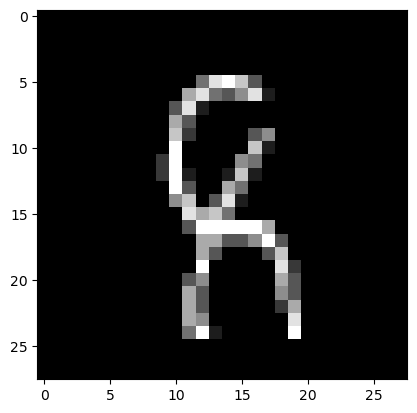

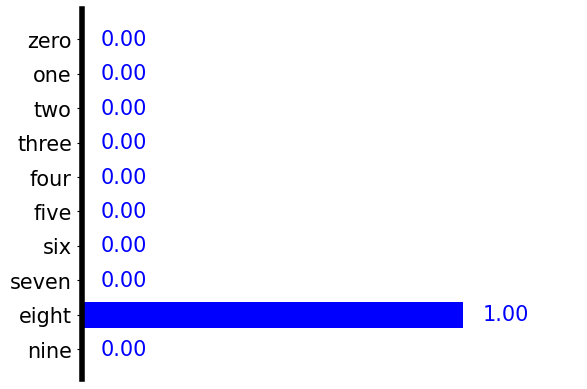

In [28]:
# choose a picture at random
idx=randint(0, 10000-1)
im=test_data[idx]

# diplay the picture
utils.show(im)

# send to device, rescale, and view as a batch of 1 
im = im.to(device)
im= (im-mean) / std
im=im.view(1,28,28).unsqueeze(dim=1)

# feed it to the net and display the confidence scores
scores =  net(im) 
probs= torch.softmax(scores, dim=1)
utils.show_prob_mnist(probs.cpu())